### Testing code
**Unit tests:**
- the developer tests their code as they write it

**Functional tests:**
- a tester, other than the developer tests code prior to deployment

**Integration tests:**
- combine modules and test them as a group. Checks whether combined modules provide expected behaviour.

**Main goal:**

To learn how use the `pytest` module in performing unit tests.



# Before you go testing

- it is preferrable to use an IDE such as PyCharm or VS Code for this topic
- always separate your test code from your application code. For example, if your application code is contained in a Python module called `calculator.py`, your test cases should be contained in a module suitably named, e.g., `test_calculator.py`
- you run your tests using the command `pytest -v test_calculator.py`
- always write your tests first, run your tests, then write your application code, then run your tests again, then refactor if need be

### Test Driven Development
An approach to writing software that emphasises writing tests to features, and then writing the features to pass the tests.

The workflow goes something like this:
1. You have an idea for a feature you want to write
2. Write a test for the feature. 
3. Run the test -the test will fail because the feature does not exist yet
4. Write the feature
5. Run the test again - this time, test passes (hopefully)


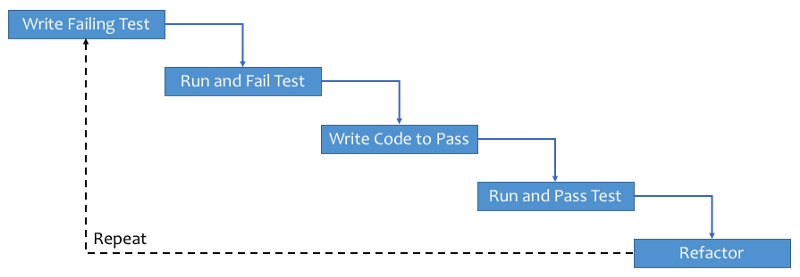

### Questions
- Why do you think this approach (TDD) development is advocated? 
- Tests aren't the real deal, so, is it not a waste of time spending time on them instead of the features?

## Useful things:

Getting started
- Create a Virtual Environment
- Install `pytest`

We will adopt this approach:
- create a test module - the one to contain your tests
- create a feature module - the one to contain the code you wish to test

## Creating a virtiual environment

- the idea is to create "separate" environment for specific projects
- install the libraries you like there and isolate system directories
- use venv module
- each virtual environment has its own Python Binary matching the version used to create the environment

## Process 
- Create a project directory in your file system, e.g,. mkdir py_tdd<br>
`skanyaru@Ss-MacBook-Pro-2 Python_TDD % mkdir py_tdd`
- Change directory to the directory created above <br>
`skanyaru@Ss-MacBook-Pro-2 Python_TDD % cd py_tdd`


## Now create the environment
- we create an environment called `pytest_env` as follows - `skanyaru@Ss-MacBook-Pro-2 py_tdd % python3 -m venv pytest_env` 
- this creates the <b>pytest_env</b> directory, and also creates directories inside it containing a copy of the Python interpreter, the standard library, and various supporting files.

## Activate the evironment
- Once environment is created activate it as follows:
    - on Windows do: `pytest_env\Scripts\activate.bat`
    - on Linux or Mac do: `source pytest_env/bin/activate`
    
Your directory path should now look like this `(pytest_env) skanyaru@Ss-MacBook-Pro-2 py_tdd % `

## Install `pytest`

Run the command `pip install pytest`

Now, open your pytest_venv in your IDE or at least work from within using your CLI.

Check `pytest` has been installed by running **pytest --version**


In [4]:
!pytest -V

pytest 9.1.0


In [5]:
%%writefile test_add.py
def test_add():
    assert add(1,2) == 3

Writing test_add.py


In [6]:
!pytest -v test_add.py

============================= test session starts ==============================
platform darwin -- Python 3.13.9, pytest-9.1.0, pluggy-1.5.0 -- /opt/anaconda3/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/johnkanyaru/Documents/Python Advanced/Day 2/Testing
plugins: langsmith-0.7.6, anyio-4.10.0, typeguard-4.5.1, fugue-0.9.7
collected 1 item                                                               

test_add.py::test_add FAILED                                             [100%]

=================================== FAILURES ===================================
___________________________________ test_add ___________________________________

    def test_add():
>       assert add(1,2) == 3
               ^^^
E       NameError: name 'add' is not defined

test_add.py:2: NameError
=========================== short test summary info ============================
FAILED test_add.py::test_add - NameError: name 'add' is not defined
=========

### Writing a `pytest` test
Let's discover our way around `pytest`

1. Create a new Project inside your `pytest_env` folder. 

2. In your project, create a module called `test_calculator`

**Let's consider exactly what we want to test**

`add(2,4) == 6`

#### Let's explain this

- The test we want to perform goes like this: there will be a `add()` function available in the system that accepts two integers. 
- If the two integers are 2 and 4 the function will return 6.

The above statement says many things that are tested:

- the function exists and can be accessed (via import)
- the function accepts two integers
- passing 2 and 4 as inputs to the function, the function will output 6.

**at this stage there is no code that implements the function `add()`,  the tests will definitely fail**


In [1]:
# write into test_calculator.py file
def test_add():
    assert add(2,4) == 6

### Invoke pytest to run tests
At your command prompt, type `pytest`
- the result will be `FAILED test_calculator.py::test_add - NameError: name 'add' is not defined`

`pytest` does look for tests in files with names starting with `test_` e.g. **test_xyz.py**
or ending with `_test.py` e.g **xyz_test.py**

### Making some progress - write the add function
Our test failed.
Let's create a module - `calculator.py`, and in it, write our add function.
Your Calculator module should have the content:


In [ ]:
def add(a, b):
    return a + b

In the test_calculator module, import the add function from calculator. Your test module should now be as follows:

In [ ]:
from calculator import add

 
def test_add():
    assert add(2, 4) == 6

In [ ]:
!pytest -v test_calc.py

Run your test again using the command **pytest**
This time, there is no error with regards to add() function.

Issue the command **pytest -v**   [v = verbose]. This gives you some more information about the passing or failing tests, even with color coding

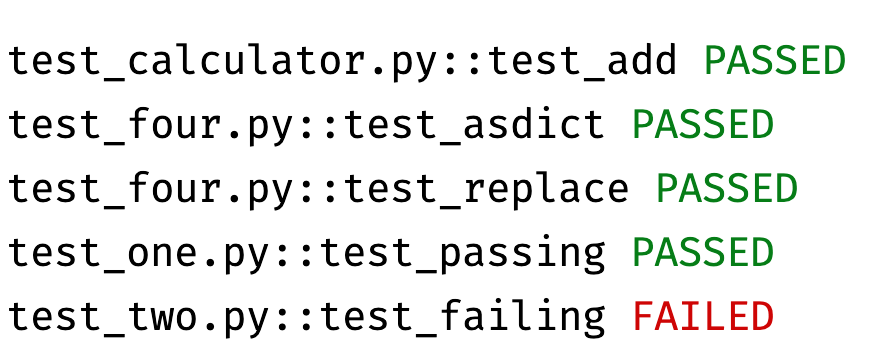



### Recap on TDD

1. Write a test for a feature that fails
2. Write code to make the test pass
3. Refactor the code as needed

Also known as **Red - Green - Refactor**

You write an automated test for how the new code should behave and see it fail - **Red**

Write code in the application until your test passes - **Green**

**Refactor** the code to make it readable and efficient. There's no need to be worried that your refactoring will break the new feature, you simply need to rerun the test and ensure it passes.
A feature is complete when we no longer need to write code for its tests to pass.


**Why write tests first?**
- Writing tests require that you know the inputs and output to make the feature work - TDD forces us to think about the application interface before we start coding.
- Increased confidence in codebase - By having automated tests for all features, developers feel more confident when developing new features. It becomes trivial to test the entire system to see if new changes broke what existed before.
- TDD does not eliminate all bugs, but the likelihood of encountering them are lower - When trying to fix a bug, you can write a test for it to ensure it's fixed when done coding.
- Tests can be used as further documentation. As we write the inputs and outputs of a feature, a developer can look at the test and see how the code's interface is meant to be used.

## Going back to our test
The `add()` function passed for 2 arguments.
If we presume to want to check addition of more than 2 values, we will get in trouble


In [ ]:
def test_add():
    assert add(2, 4, 5) == 11
    
    # change your test as above and run it
    # it will fail.

### What to do to get our test to pass

**Refactor** the implementation code

In [ ]:
def add(*args):
    return sum(args)

## Task 1
**Write more tests in your test_calculator**

The tests should be named and test the following behaviours:

- `sub()`:  for subtraction; here test that given two params a and b, we can obtain their differe (a-b)
- `mul()` : given an unlimited number of values, we can return a product
- `div()` : given two params, we can return the quotient e.g a/b. Handle Zero Division exception 
- `avg()` : given a list of values, we can return the average. Use an iterable for this
- `is_prime()` - takes an argument and returns true if the value is a prime number, false otherwise
    

In [1]:
#3*"python"

'pythonpythonpython'

**Working on the prime feature**

In our test_calculator.py, we add the test for prime:

In [ ]:
def test_prime_low_number():
    assert is_prime(1) == False
    
    
    # run your test and this will fail

Now add the is_prime function in your implementation:

In [ ]:
def is_prime(num):
    if num == 1:
        return False

**Amend your test module as below**

In [ ]:
from calculator import add, is_prime


def test_add():
    assert add(2, 4, 5) == 11


def test_prime_low_number():
    assert is_prime(1) == False
    
    
    # run your test, it should now pass

### Thoughts
`1` is not prime; also by definition `0` is not prime, nor is any negative number.

**Refactor** our application to reflect that and change `is_prime()` to:


In [ ]:
def is_prime(num):
    # Prime numbers must be greater than 1
    if num < 2:
        return False

If you run the test, it will pass.
Let's use different test data in our test - a test case as follows:


In [ ]:
def test_prime_number():
    assert is_prime(29)

The second test fails with the following message `FAILED test_calculator.py::test_prime_number - assert None`

The new test case fails as we don't actually compute whether number is prime or not. The `is_prime()` function returns None as other functions do by default for any number greater than 1.


**The output still fails, or we see `red` from the output.**

But what's the logic for determining whether a number is prime or not? The simplest method would be to loop from 2 until one less than the number, dividing the number by the current value of the iteration.

To make this more efficient, we can check by dividing numbers between 2 and the square root of the number.

If there's no remainder from the division, then it has a divisor that's neither 1 nor itself, and therefore not prime. If it does not find a divisor in the loop, then it must be prime.

Let's update is_prime() with our new logic:


In [ ]:
import math

def is_prime(num):
    # Prime numbers must be greater than 1
    if num < 2:
        return False
    for n in range(2, math.floor(math.sqrt(num) + 1)):
        if num % n == 0:
            return False
    return True

If your run your test, it passes.

So,  this function can get a prime number, and a low number. Let's add a test to ensure it returns False for a composite number greater than 1.

In `test_calculator.py` add the following test case:

In [ ]:
def test_non_prime():
    assert is_prime(15) == False
    
    
    # This passes, checks correctly that 15 is not a prime

### Review

- We started with a test module called `test_calculator.py`
What are it's contents all about?

- We also had another module called `calculator.py`
What is contained in it?

**Did you notice that invoking pytest will run all tests in any file with test_ in its name?**

**Question** - can we run just one testcase from the test module? **Yes**, we can, but how?



#### Task 2
Consider an application with functions to add names to a list.
The key operations are:
- return an empty list
- add a name to the list
- remove an item from the list
- obtain an item from the list

As per TDD:
1. create a test module called `test_list_operations.py`
2. write a test function to test that a function `create_list()` can create an empty list
Name your test method `test_create_empty_list()`. Run your test. It should fail.
3. Now create an application module called `list_operations.py`. 
4. In `list_operations.py` create the function `create_list()`. This function should create an empty list and return it. Run your test again.
5. In your test module, create the following tests: 
- `test_islist_type()` which should check that `create_list()` returns an object of type list.
- `test_add_to_list()` that should check a function `add_to_list()` is able to append data to the list. We can also check how many things are now in the list.
- `test_get_item()` that checks whether the function `get_item()` returns the item at a given list index

**Remember the workflow:**

- Write the test functon.
- Run the test function - which should fail.
- Write the feature that is intended for the test.
- Run the test again. If the test passes, move on to the next test.

### Unit Tests vs Integration Tests
- Unit tests -  used to ensure an individual module behaves as expected
- Integration tests -  ensure that a collection of modules interoperate as we expect them too.

As we develop larger applications, we'll have to develop many components. While these individual components may each have their corresponding unit tests, we'll also want a way to ensure that these multiple components when used together fulfill our expectations.

**TDD requires that we begin by writing a single test that fails with the current code base**, then work towards its completion. **It doesn't specify that it has be a unit test**, your first test can be an integration test if you'd like.

When your first failing integration test is written, we can then start to develop each individual component.

The integration test will fail until each component is built and passes their tests. When the integration test passes, if crafted correctly we would have met a user requirement for our system.

### Further tests
Suppose we want to test  `sum_of_primes()`.

Let's consider the outcomes of this function. 
If the input is an empty list, then the sum should be zero.

This guarantees that the function should always return a value given a valid input. 

We shall also want to test that it only adds prime numbers in a list of numbers.

Now write the first `failing` test. Add this to the `test_calculator.py` module:

In [ ]:
def test_sum_of_primes_empty_list():
    assert sum_of_primes([]) == 0

- Run `pytest` 
- the above test will fail.. `NameError: name 'sum_of_primes' is not defined`

Edit the `calculator.py` module to add the function `sum_of_primes()`

In [ ]:
def sum_of_primes(nums):
    return sum(nums)

In [ ]:
# your test module should look like this now

from calculator import add, is_prime, sum_of_primes


def test_add():
    assert add(2, 4, 5) == 11


def test_prime_low_number():
    assert is_prime(1) == False


def test_prime_number():
    assert is_prime(29)


def test_non_prime():
    assert is_prime(15) == False


def test_sum_of_primes_empty_list():
    assert sum_of_primes([]) == 0

    

All tests pass now. 

**Next test** - ensure that only prime numbers are added


Let's mix prime and composite numbers and expect the function to only add the prime numbers:

In [ ]:
## add this function to your test module

def test_sum_of_primes_mixed_list():
    assert sum_of_primes([11, 15, 17, 18, 20, 100]) == 28
    
    # prime numbers in the list we are testing are 11 + 17 =  28.

Run `pytest` to validate that the new test fails. 

It fails with error `test_sum_of_primes_mixed_list - assert 181 == 28`. **What does this mean?**

**Refactor**  the `sum_of_primes()` so that only prime numbers are added.

In [ ]:
# update old one in calculator.py
def sum_of_primes(nums):
    return sum([x for x in nums if is_prime(x)])

Run pytest to verify that the failing test is now happy - everything passes.

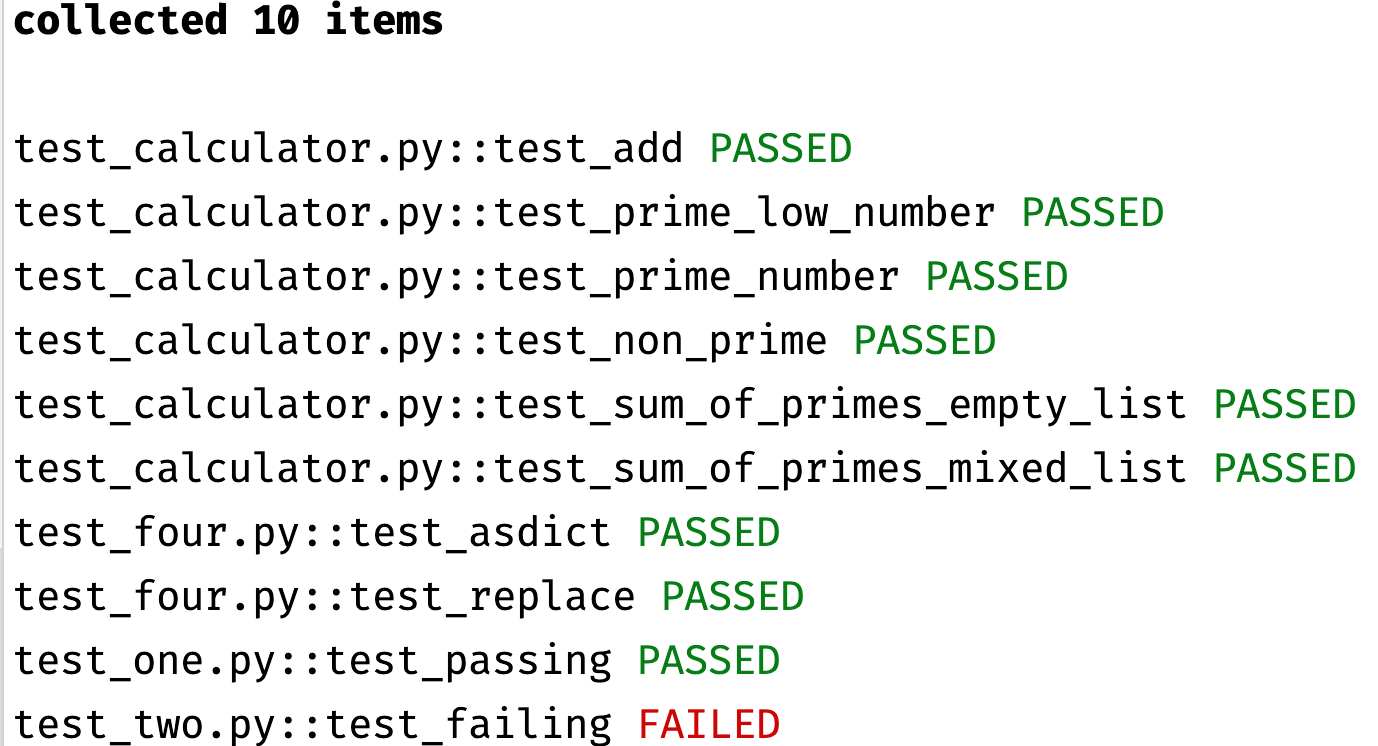

### On code coverage
 - Code coverage - **a measure of the amount of source code that's covered by your tests.**

- 100% code coverage means that all the code you've written has been used by some test(s). 

Tools measure code coverage in many different ways. Some popular metrics:

- Lines of code tested
- How many defined functions are tested
- How many branches (`if` statements for example) are tested

`pytest`  has the `pytest-cov` plugin to get code coverage.

High code coverage does not mean that your application will have no bugs. It's more than likely that the code has not been tested for every possible scenario.

### Check test coverage

You may have to install coverage module:

- check before installing ... it should already be installed typically as part of pytest, but if not ...do:

`pip install pytest-cov`

In [ ]:
pytest --cov=calculator

For this package, the code coverage is 100%

What if it wasn't?
- you spend some time adding a few more tests to the code to ensure that the test plan is thorough.

Example - if  `is_prime()` is given a float value, would it throw an error? 
The `is_prime()` function does not enforce the rule that a prime number must be a natural number, it only checks that it's greater than 1.

**Note**: even though we have total code coverage, the feature being implemented may not work correctly in all situations.

### Review 

**TDD asserts that:** 

You should decide what your function should do and how it should behave before writing it. This is an important and strangely seldom-followed approach.

### Task 2
In Python, catipalize() function capitalizes the first character of a String.

Create a file called `test_capitalize.py`. Inside it, write a function called `capital_case` which should take a string as its argument and should return a capitalized version of the string.


In [ ]:
a = 'python'
print(a.capitalize())

In [ ]:
def test_capital_case():
    assert capital_case('python') == 'Python'
    
# run your test and note the outcome


- Creat a module called `caps.py`. In it create the feature needed to get your test to pass.
- import the feature in your test case
- run the test with sample string values of your choice

**What happens if we pass a numeric value to your feature?**

An attribute error is thrown. We need to write another test to cater for that use case.

Add the test case below to your `test_capitalize.py` module

In [ ]:
def test_raises_exception_on_non_string_arguments():
    with pytest.raises(TypeError):
        capital_case(9)

Run your tests again, the test will indeed confirm we have not handled this case in our feature.

Now we go to the feature function and solve it. 
In the `caps.py` module, revise your feature as follows:


In [ ]:
def capital_case(x):
    if not isinstance(x, str):
        raise TypeError('Please provide a string argument')
    return x.capitalize()

**Run your tests again**

Do they pass?

### Task 3
Let's write a function that computes the number of negatively charged residues in a protein. This involves counting the number of glutamate `E` and aspartate `D` residues. Let our protein be represented as a string literal.



**Let's write a test function for this behaviour**

Place the test function below in a module called test_proteins

In [ ]:
def test_number_negatives():
    """Perform unit tests on n_neg."""
    assert number_negatives('E') == 1
    assert number_negatives('D') == 1
    assert number_negatives('') == 0
    assert number_negatives('ACKLWTTAE') == 1
    assert number_negatives('DDDDEEEE') == 8
    assert number_negatives('acklwttae') == 1

Run `pytest -v`, the test fails with ` NameError: name 'number_negatives' is not defined`

Now create a module **proteins** and place the function below in it

In [ ]:
def number_negatives(seq):
    """Number of negative residues in a protein sequence"""
    # Convert sequence to upper case
    seq = seq.upper()

    # Count E's and D's, since these are the negative residues
    return seq.count('E') + seq.count('D')

**Now, modify  `test_proteins.py`**

In [ ]:
from proteins import number_negatives


def test_number_negatives():
    """Perform unit tests on n_neg."""
    assert number_negatives('E') == 1
    assert number_negatives('D') == 1
    assert number_negatives('') == 0
    assert number_negatives('ACKLWTTAE') == 1
    assert number_negatives('DDDDEEEE') == 8
    assert number_negatives('acklwttae') == 1

Now run `pytest -v` to check that the test passes.


### Organise  tests into functional units
Our tests are placed in one test function. This can become problematic when fixing problems. 

- `pytest` allows us to build multiple test functions
- each test function should be given a name that indicates what they are testing. 

We now **refactor** the content of the file `test_proteins.py` to become more granular:

In [ ]:
from proteins import number_negatives


def test_number_negatives_for_single_AA():
    """Perform unit tests on number_negative for single AA"""
    assert number_negatives('E') == 1
    assert number_negatives('D') == 1


def test_number_negatives_for_empty():
    """Perform unit tests on number_negative for empty entry"""
    assert number_negatives('') == 0


def test_number_negatives_for_short_sequence():
    """Perform unit tests on number_negative for short sequence"""
    assert number_negatives('ACKLWTTAE') == 1
    assert number_negatives('DDDDEEEE') == 8


def test_number_negatives_for_lowercase():
    """Perform unit tests on number_negative for lowercase"""
    assert number_negatives('acklwttae') == 1

**Run `pytest -v` to check that the refactored test module works fine.**

You can also do `pytest -v test_proteins.py`

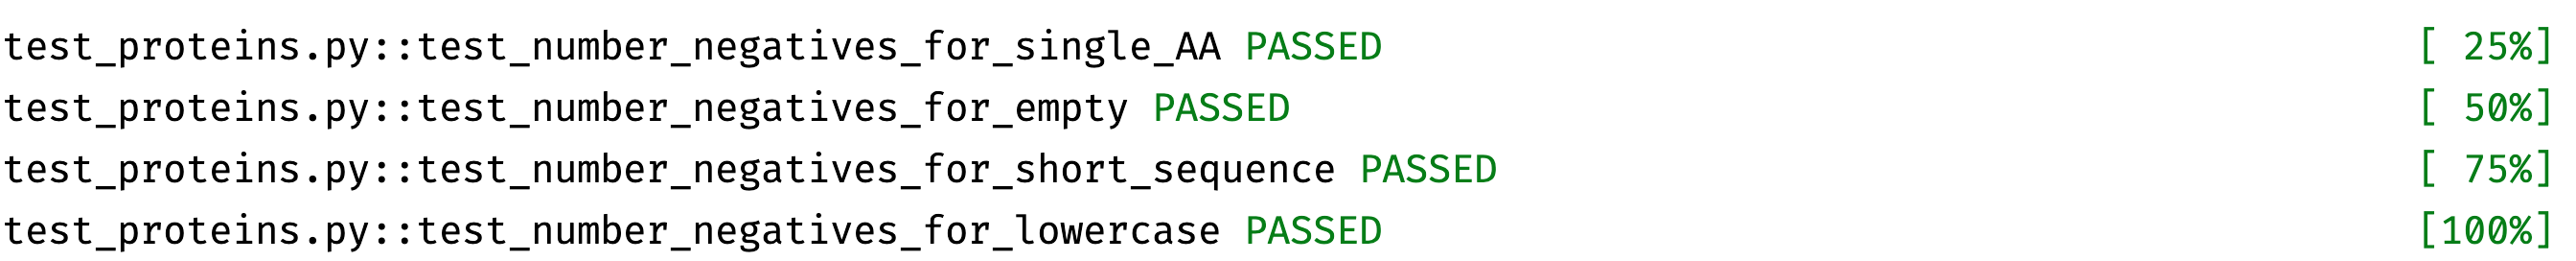



### Handling `exceptions` in assertions

What is the difference between an `exception` and an `assertion`?

- raise exceptions when we are checking inputs to our function - is the user using the function properly?
- use assertions to ascertain the function operates as expected for given input


**Revisit the test_proteins.py module**

Suppose an invalid sequence is entered, what to do? We should add to raise an exception when that happens.



In [ ]:
# ensure these imports are in place - import proteins; import pytest
def test_number_negatives_for_invalid_amino_acid():
    with pytest.raises(RuntimeError) as excinfo:
        proteins.number_negatives('Z')
    excinfo.match("Z is not a valid amino acid")


Run `pytest -v test_proteins.py` 

The outcome is ` Failed: DID NOT RAISE <class 'RuntimeError'>`

To fix the issue, **refactor** the `number_negatives()` function in `proteins.py` module as follows:


In [ ]:
def number_negatives(seq):
    """Number of negative residues a protein sequence"""
    # Convert sequence to upper case
    seq = seq.upper()

    if seq == 'Z':
        raise RuntimeError('Z is not a valid amino acid.')

    # Count E's and D's, since these are the negative residues
    return seq.count('E') + seq.count('D')

Run the test again: 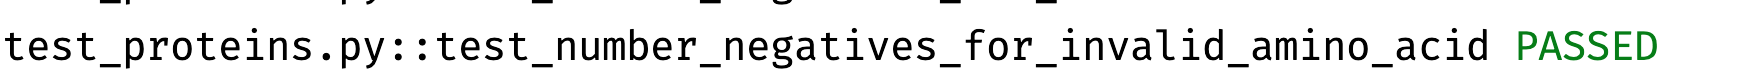


The test passes, but it only works when the input amino acid is `Z`. This is not robust enough.

 There is a module called **bootcamp-utils** that provides us with `bootcamp_utils.aa`. Install the module by pip install `bootcamp-utils`, then in the `proteins.py` file do `import bootcamp_utils`. 
 
 Finally modify the function `number_negative()` as follows: seq_features:

In [ ]:
import bootcamp_utils

def number_negatives(seq):
    """Number of negative residues a protein sequence"""
    # Convert sequence to upper case
    seq = seq.upper()

    # Check for a valid sequence
    for aa in seq:
        if aa not in bootcamp_utils.aa.keys():
            raise RuntimeError(aa + ' is not a valid amino acid.')

    # Count E's and D's, since these are the negative residues
    return seq.count('E') + seq.count('D')

Now run the test even with other non-negative sequence and it will pass.

### Task 4

Consider the following Test case.

Create test module called `test_data.py`

In it ...add the following tests

In [14]:
import pytest

def test_user_database():
    # Create user database object
    database = UsersDatabase()

    # Add new users
    database.add_user('John', 'Smith', 29, 'e31sf')
    database.add_user('Emily', 'Taylor', 12, 'd24da')
    database.add_user('Lily', 'Thomas', 66, 'd33fw')
    assert database.get_number_of_users() == 3
    
    # Add two users with the same id
    with pytest.raises(ValueError):
        database.add_user('John', 'Smith', 29, 'e31sf')

    # Remove user
    database.delete_user_by_id('d24da')
    assert database.get_number_of_users() == 2
 
    # What if age is a string
    with pytest.raises(TypeError):
        database.add_user('John', 'Thomas', 'age', 'dc33s')

    # What if age equals 200
    with pytest.raises(ValueError):
        database.add_user('Ava', 'Brown', 200, 'dsd2f')

    # What if age is negative value
    with pytest.raises(ValueError):
        database.add_user('Ava', 'Brown', -10, 'dsdw3')

    # What if name is a integer
    with pytest.raises(TypeError):
        database.add_user(2323, 'Smith', 23, 'd3ff2')

    # What if surname is a float
    with pytest.raises(TypeError):
        database.add_user('John', 3.14, 19, 'd31xe')

    # What if new user doesn't have id
    with pytest.raises(TypeError):
        database.add_user(name='John', surname='Wilson', age=19)

**Run tests on this module and observe it failing**

- Create your application code module as follows. 
- Create a module called `usersDB.py`. 
- In it add the following code:

In [13]:
!pytest -v test_data.py

============================= test session starts ==============================
platform darwin -- Python 3.13.9, pytest-9.1.0, pluggy-1.5.0 -- /opt/anaconda3/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/johnkanyaru/Documents/Python Advanced/Day 2/Testing
plugins: langsmith-0.7.6, anyio-4.10.0, typeguard-4.5.1, fugue-0.9.7
collected 1 item                                                               

test_data.py::test_user_database PASSED                                  [100%]

============================== 1 passed in 0.00s ===============================


In [8]:

class UsersDatabase:
    def __init__(self):
        self.database = []

    def add_user(self, name, surname, age, id_number):
        if not isinstance(age, int):
            raise TypeError

        if not isinstance(name, str):
            raise TypeError
 
        if not isinstance(surname, str):
            raise TypeError

        if age not in range(1, 120):
            raise ValueError

        if any(user.id_number == id_number for user in self.database):
            raise ValueError

        self.database.append(User(name, surname, age, id_number))

    def delete_user_by_id(self, id_number):
        for user in self.database:
            if user.id_number == id_number:
                self.database.remove(user)

    def get_oldest_user_name(self):
        oldest_user = sorted(self.database, key=lambda x: x.age, reverse=True)[0]
        return oldest_user.name 

    def get_number_of_users(self):
        return len(self.database)

class User:
    def __init__(self, name, surname, age, id_number):
        self.name = name
        self.surname = surname
        self.age = age
        self.id_number = id_number

Writing data.py


For you To do:
- import your application in your test case
- run the test
- add unit tests for the other methods - delete especially

### Task 5 - Summary 
**Running tests using `pytest`**

Without arguments, `pytest` looks at the current working directory and all subdirectories for test files and runs the test code it finds.

- To run all test files in the current directory, simply type `pytest` at your prompt.
- To run tests in a specific file (e.g., test_min_max.py) do `pytest test_min_max.py`
- To run a specific function e.g. test_min) we do `pytest test_min_max.py::test_min`
- Alternative way to run the test on a specific function - provide it's name e.g., 


### The task
We want to write a Python module, `algorithm.py` with two functions as follows:
- `biggest()` - to return the biggest value in a tuple
- `smallest()` - returns the smallest value in a tuple

In [ ]:
def biggest(values):
    pass


def smallest(values):
    pass


**Now write your test case**
Place your test cases in a Python module called `test_algorithm.py`


In [ ]:
def test_smallest():
    pass

def test_biggest():
    pass

1. Run your test on the test module `pytest test_algorithm.py` or do `pytest -v test_algorithm.py`
2. Let's skip one test:
    - import pytest
    - decorate test_smallest as follows



In [ ]:
@pytest.mark.skip
def test_smallest():
    pass 